# Esperimenti tesi

Il primo esperimento che voglio fare è fittare una serie di alberi con diverse profondità su dei dati sintetici $y \in \{1,-1\}$ e verificare se la differenza tra l'errore su un training set ($\hat R$) e l'errore su un test set ($R$) segue l'andamento previsto dal bound teorico
\begin{equation}
0 \le \mathbb{E}_D[R(\hat f_D)-\hat R(\hat f_D)] \le 2 \sqrt{\frac{\log \vert \mathcal{H}\vert}{2n}}
\end{equation}
cioè aumenta all'aumentare della profondità del mio albero in un modo controllato. 

N.B. parlo di profondità perché nel caso degli alberi, la cardinalità dell'insieme di ipotesi $\mathcal{H}$ è proporzionale alla profondità, in altre parole più profondo l'albero più comlpesso il modello che impariamo. 

### dati

Costruiamo un dataset sintetico di size $n$, secondo la legge 
\begin{gather}
x \sim \mathrm{Unif}(\text{supp}(0,10))\tag{2}\\
y \coloneqq \mathrm{sign}(f(x) + \varepsilon), \quad \varepsilon \sim \mathcal{N}(0,\sigma^2)\tag{3}
\end{gather}
for some $f: X \to Y$ convex and where $\text{supp}(0,10)$ is a discretization of the interval $[0,10]$ into $N$ points.  

we want 
\begin{equation}
n_\text{train} \ll N \ll n_\text{test} \approx \infty
\end{equation}

### modelli e plot
we train **binary trees** with depths ranging from 1 to a multiple of the $\log_2 n$ threshold to see long term trends, using a **counting loss**. 

we compute the expected values of $R$ and $\hat R$ (and their difference) over the disorder of the data $D$ averaging over a number of training samples equal to ```max_iter```. 

we then do a number of plots to visualize to what extent empirical results confirm the theoretical bound $\text{(1)}$. 


In [1]:
print('mare')

mare


In [ ]:
# build dataset

import numpy as np

rng = np.random.default_rng(seed=4)  

def sample_x(data_size, supp_size, l=0.0, u=10.0, rng=rng):
    """sample n points from supp evenly spaced points on [l, u]"""
    support = np.linspace(l, u, supp_size)
    return rng.choice(support, size=data_size, replace=True)

def sample_y(x, f, sigma=1.0, rng=rng):
    """y = sign(f(x) + e), e ~ N(0, sigma)"""
    e = sigma * rng.standard_normal(size=len(x))
    return np.sign(f(x) + e)

def sample_y_bernoulli(x, f, p=0.8, rng=rng):
    """y = sign(f(x)) * b, b = +1 w.p. p, b = -1 w.p. 1-p"""
    b = rng.choice(np.array([1, -1]), size=len(x), p=[p, 1 - p])
    return np.sign(f(x)) * b

# almost-always-fixed details

def get_depths_list(t):
    depths = np.arange(1, int(np.floor(7 * t)) + 1)
    depths_float = depths.astype(float)
    return depths, depths_float

def centered_parabola(x):
    return (x-5)**2 - 6.25

# build model and create plots

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

def main_loop(x_test, y_test, n_train, sigma, max_iter, model,  N=10_000,
              fun=centered_parabola):
    
    '''
    function to build models and obtain the exp values of R, R_hat, and their difference for a number of depths.

    for each depth:
    sample a training set max_iter times;
    fit model;
    compute the metrics;
    average at the end to cancel the disorder over the data randomness. 

    return lists of the 3 metrics, one value for each depth. 
    '''

    # overfitting threshold
    if model == DecisionTreeClassifier:
        threshold = np.log2(n_train)
        depths_list, _ = get_depths_list(threshold)
    
    # if no threshold logic is specified for the model, hardcode max depth at 70
    else:
        depths_list, _ = get_depths_list(10)

    E_hat_Rs = []; E_Rs = []; E_gaps = []
    for d in depths_list:
        hat_Rs = []; Rs = []; gaps = []
        for i in range(max_iter):
            # sample training data
            x = sample_x(n_train, N)
            y = sample_y(x, fun, sigma)
            # fit model to training data
            clf = model(max_depth=int(d), random_state=42)
            clf.fit(x.reshape(-1, 1), y)
            # compute errors and gap
            train_err = 1 - clf.score(x.reshape(-1, 1), y)
            test_err  = 1 - clf.score(x_test.reshape(-1, 1), y_test)
            gap = test_err - train_err
            hat_Rs.append(train_err); Rs.append(test_err); gaps.append(gap)

        # out of the max_iter loop, we append the avg value for the current depth d   
        E_hat_Rs.append(np.mean(hat_Rs))
        E_Rs.append(np.mean(Rs))
        E_gaps.append(np.mean(gaps))

    return np.array(E_hat_Rs), np.array(E_Rs), np.array(E_gaps)


def plots(E_hat_Rs, E_Rs, E_gaps, 
          # variables for visualizations in the plots
          n_train, sigma, 
          # variable for obtaining useful quantities
          model,
          one=True, two=True, three=True,
          axes=None):
    
    '''
    function to obtain the following plots, given the metrics obtained with main_loop():

    1) classical train vs. test error plot, against depth of the model;
    2) plots the empirical gap and the theoretical function that should upper bound the gap depending on the depth;
    3) plots the same as (2) with as RHS E[hat_R] + bound.
    '''
    
    # quantities for plotting overft threshold and the bound function
    if model == DecisionTreeClassifier:
        threshold = np.log2(n_train)
        _, depths_list_float = get_depths_list(threshold)
        bound = 2 * np.sqrt(np.log(depths_list_float) / (2 * n_train))

    # se per il modello scelto non c'è una logica per overft threshold e bound, fai
    else:
        # evita di disegnare overft line
        threshold = False
        # hardcode un numero di depths fino a 70
        _, depths_list_float = get_depths_list(10)
        # non disegnare i grafici che hanno bisogno di un bound
        two, three = False, False
        print('AA: you are only getting the first plot as you did not specify overfitting and bound for this model :)')

    # cluade logic for getting multiple plots at a time
    n_plots = sum([one, two, three])
    if n_plots == 0:
        return
    if axes is None:
        fig, axs = plt.subplots(n_plots, 1, figsize=(10, 5 * n_plots))
        if n_plots == 1:
            axs = [axs]
    else:
        axs = axes
    ax_iter = iter(axs)

    if one:
        #1: grafico solito train e test error
        ax = next(ax_iter)
        zero_train = next((d for d, e in zip(depths_list_float, E_hat_Rs) if e == 0), None)
        ax.plot(depths_list_float, E_hat_Rs, color='#FF007F', marker='o', label=r'$E[\hat R]$')
        ax.plot(depths_list_float, E_Rs,     color='#00CED1', marker='o', label=r'$E[R]$')
        # logica per if-else above (overft threshold a 0, se computato esplicitamente, non ha senso quindi ignoro il caso)
        if threshold:
            ax.axvline(threshold, color='red',  linestyle='--', linewidth=1.2, label='theoretical overfitting th.')
        # questo è per plottare empirical overft threshold
        # if zero_train is not None:
        #     ax.axvline(zero_train, color='blue', linestyle='--', linewidth=1.2, label='empirical overfitting th.')
        ax.set_ylim(bottom=0)
        ax.set_title(f'train vs test error for different depths (n={n_train}, noise std = {sigma})')
        ax.set_xlabel('depth'); ax.set_ylabel('error')
        ax.legend(); ax.grid(True, alpha=0.3)

    if two:
        #2: grafico che confronta il bound teorico e il gap empirico
        ax = next(ax_iter)
        zero_train = next((d for d, e in zip(depths_list_float, E_hat_Rs) if e == 0), None)
        ax.plot(depths_list_float, E_gaps, color='#32CFFFFF', marker='o', label=r'$E[R - \hat R]$')
        ax.plot(depths_list_float, bound,  color='gray', linestyle='--', label=r'$2\sqrt{\frac{\log d}{2n}}$')
        if threshold:
            ax.axvline(threshold, color='red',  linestyle='--', linewidth=1.2, label='theoretical overfitting th.')
        # if zero_train is not None:
        #     ax.axvline(zero_train, color='blue', linestyle='--', linewidth=1.2, label='empirical overfitting th.')
        ax.set_ylim(bottom=0)
        ax.set_title(f'gap between train and test error for different depths (n={n_train}, noise std = {sigma})')
        ax.set_xlabel('depth'); ax.set_ylabel('gap')
        ax.legend(); ax.grid(True, alpha=0.3)

    if three:
        #3: grafico che confronta la LHS E[R] con la RHS E[hat_R] + bound
        ax = next(ax_iter)
        zero_train = next((d for d, e in zip(depths_list_float, E_hat_Rs) if e == 0), None)
        RHS = E_hat_Rs + bound
        ax.plot(depths_list_float, E_Rs,  color='#FD6428FF', marker='o', label=r'$E[R]$')
        ax.plot(depths_list_float, RHS,   color='#6BC615FF', linestyle='--', marker='s', label=r'$E[\hat R] + 2\sqrt{\frac{\log d}{2n}}$')
        if threshold:
            ax.axvline(threshold, color='red',  linestyle='--', linewidth=1.2, label='theoretical overfitting th.')
        # if zero_train is not None:
        #     ax.axvline(zero_train, color='blue', linestyle='--', linewidth=1.2, label='empirical overfitting th.')
        ax.set_ylim(bottom=0)
        ax.set_title(f'$E[R] \leq E[\hat R]$ + bound  (n={n_train}, noise std = {sigma})')
        ax.set_xlabel('depth'); ax.set_ylabel('error')
        ax.legend(); ax.grid(True, alpha=0.3)

    if axes is None:
        plt.tight_layout()
        plt.show()

### experiments




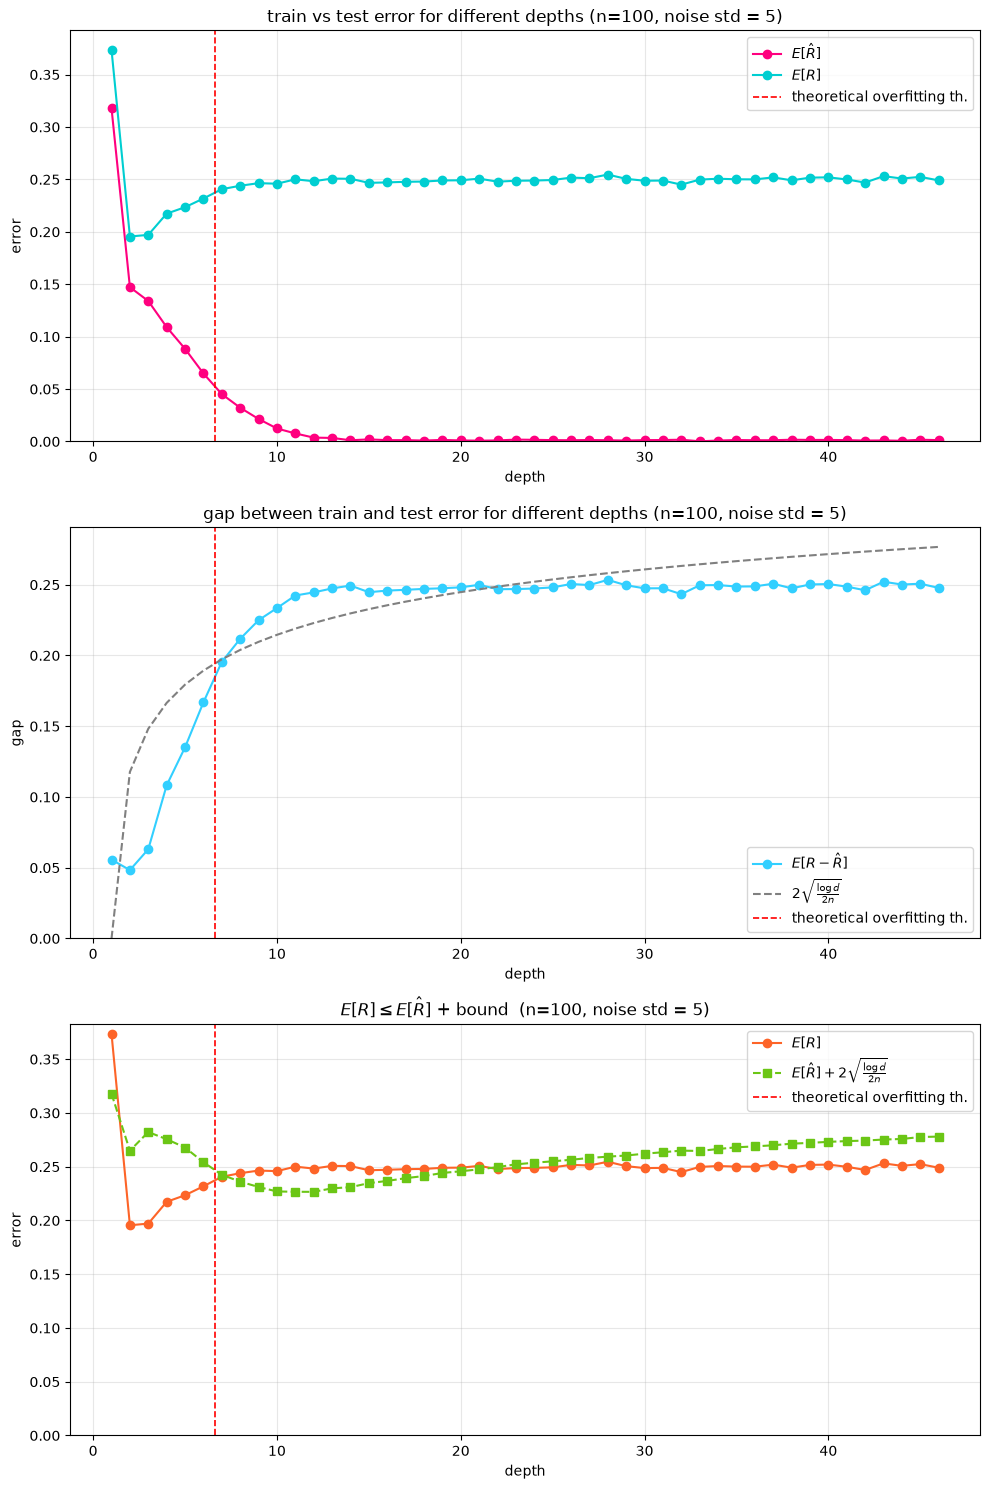

In [12]:
# MODEL
mymodel = DecisionTreeClassifier

# PARAMETERS
N = 10_000
n_test = 200_000
n = 100
noise_std = 5
T = 100

# build test set
x_test = sample_x(n_test, N)
y_test = sample_y(x = x_test, f = centered_parabola, sigma = noise_std)

# build models and do plots
hat_Rs, Rs, gaps = main_loop(x_test, y_test, n_train = n, sigma = noise_std, max_iter = T, model = mymodel)
plots(hat_Rs, Rs, gaps, n_train = n, sigma = noise_std, model = mymodel)